# WEEK 2 - Data Collection and Understanding

This section imports the Customer Personality Analysis dataset and examines its structure, variables, data types, and general characteristics.

In [7]:
# Import pandas for data manipulation and analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import StratifiedGroupKFold

In [8]:
# Load the Customer Personality Analysis dataset
df = pd.read_csv("../data/raw/marketing_campaign.csv", sep="\t")

# Display the first five rows
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [9]:
# Display the dimensions of the dataset
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 2240
Number of columns: 29


In [10]:
# Display column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [11]:
# Check the number of missing values in each column
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [12]:
# Display summary statistics for the numberical variables
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [13]:
# Display the unique values for the categorical variables
print("Education:", df["Education"].unique())
print("Marital Status:", df["Marital_Status"].unique())

Education: ['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']
Marital Status: ['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']


In [14]:
# Display the frequency of each categorical value
print("Education Counts:")
print(df["Education"].value_counts())

print("\nMarital Status Counts:")
print(df["Marital_Status"].value_counts())

Education Counts:
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

Marital Status Counts:
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


In [15]:
# Examine the distribution of the target variable
response_counts = df["Response"].value_counts()
response_percentages = df["Response"].value_counts(normalize=True) * 100

print("Response Counts:")
print(response_counts)

print("\nResponse Percentages:")
print(response_percentages.round(1))

Response Counts:
Response
0    1906
1     334
Name: count, dtype: int64

Response Percentages:
Response
0    85.1
1    14.9
Name: proportion, dtype: float64


In [16]:
# Check the unique values of the suspected constant columns
print("Z_CostContact unique values:")
print(df["Z_CostContact"].unique())

print("\nZ_Revenue unique values:")
print(df["Z_Revenue"].unique())

Z_CostContact unique values:
[3]

Z_Revenue unique values:
[11]


In [17]:
# Examine unusually early birth years
print("Earliest birth years:")
print(df["Year_Birth"].sort_values().head(10))

print("\nCustomers born before 1940:")
print(df[df["Year_Birth"] < 1940][["ID", "Year_Birth"]])

Earliest birth years:
239     1893
339     1899
192     1900
1950    1940
424     1941
1150    1943
415     1943
2084    1943
358     1943
1923    1943
Name: Year_Birth, dtype: int64

Customers born before 1940:
        ID  Year_Birth
192   7829        1900
239  11004        1893
339   1150        1899


In [18]:
# Examine the highest income values for potential outliers
print("Highest income values:")
print(df["Income"].sort_values(ascending=False).head(10))

print("\nCustomers with income above $150,000:")
print(df[df["Income"] > 150000][["ID", "Income"]].sort_values("Income", ascending=False))

Highest income values:
2233    666666.0
617     162397.0
687     160803.0
1300    157733.0
164     157243.0
1653    157146.0
2132    156924.0
655     153924.0
1898    113734.0
646     105471.0
Name: Income, dtype: float64

Customers with income above $150,000:
         ID    Income
2233   9432  666666.0
617    1503  162397.0
687    1501  160803.0
1300   5336  157733.0
164    8475  157243.0
1653   4931  157146.0
2132  11181  156924.0
655    5555  153924.0


In [19]:
# Examine acceptance counts for previous marketing campaigns
campaign_columns = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5"
]

print("Previous Campaign Acceptance Counts:")
for column in campaign_columns:
    print(f"\n{column}:")
    print(df[column].value_counts().sort_index())

Previous Campaign Acceptance Counts:

AcceptedCmp1:
AcceptedCmp1
0    2096
1     144
Name: count, dtype: int64

AcceptedCmp2:
AcceptedCmp2
0    2210
1      30
Name: count, dtype: int64

AcceptedCmp3:
AcceptedCmp3
0    2077
1     163
Name: count, dtype: int64

AcceptedCmp4:
AcceptedCmp4
0    2073
1     167
Name: count, dtype: int64

AcceptedCmp5:
AcceptedCmp5
0    2077
1     163
Name: count, dtype: int64


In [20]:
# Examine the range of customer enrollment dates
customer_dates = pd.to_datetime(
    df["Dt_Customer"],
    format="%d-%m-%Y"
)

print("Earliest enrollment date:", customer_dates.min())
print("Latest enrollment date:", customer_dates.max())
print("Number of unique enrollment dates:", customer_dates.nunique())

Earliest enrollment date: 2012-07-30 00:00:00
Latest enrollment date: 2014-06-29 00:00:00
Number of unique enrollment dates: 663


In [21]:
# Check for duplicate rows in the dataset
duplicate_rows = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


### Key Exploration Findings

- The dataset contains 2,240 customer records and 29 variables.
- Income is the only variable with missing values, with 24 missing observations.
- No duplicate rows were identified.
- Education and marital status contain several categorical groups, including a few uncommon marital status values.
- The target variable, Response, is imbalanced: 334 customers (14.9%) responded to the most recent campaign, while 1,906 (85.1%) did not.
- Z_CostContact and Z_Revenue are constant across all observations and therefore provide no variation.
- Three unusually early birth years (1893, 1899, and 1900) were identified for further investigation.
- Income contains several unusually high values, including one observation of $666,666.
- Customer enrollment dates range from July 2012 through June 2014.

---

## END OF WEEK 2 

WEEK 3 - START

In [23]:
# Check for customers with identical records under different IDs
feature_columns = [c for c in df.columns if c not in ("ID", "Response")]

print("Are all IDs unique?", df["ID"].is_unique)
print("Rows sharing an identical record with another row:",
      df.duplicated(subset=feature_columns, keep=False).sum())
print("Extra copies:", df.duplicated(subset=feature_columns).sum())

# Check whether any identical records have different Response labels
dup_rows = df[df.duplicated(subset=feature_columns, keep=False)]
conflicts = dup_rows.groupby(feature_columns, dropna=False)["Response"].nunique()
print("Identical records with conflicting Response labels:", (conflicts > 1).sum())

Are all IDs unique? True
Rows sharing an identical record with another row: 394
Extra copies: 201
Identical records with conflicting Response labels: 19


In [24]:
# Split into 80% training and 20% test
# - Stratified on Response so both sets keep the ~15% response rate
# - Group-aware so identical records always land in the same set

# Give each unique customer record a group number (duplicates share a number)
group_key = df[feature_columns].astype(str).agg("|".join, axis=1)
groups = pd.factorize(group_key)[0]

# Create 5 folds (~20% each) and use the first fold as the test set
splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(splitter.split(df, y=df["Response"], groups=groups))

train_df = df.iloc[train_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

# Confirm no rows were lost and no duplicate group appears in both sets
assert len(train_df) + len(test_df) == len(df)
assert set(groups[train_idx]).isdisjoint(groups[test_idx])

print("Training set:", train_df.shape, "| Response rate:", round(train_df["Response"].mean() * 100, 1), "%")
print("Test set:", test_df.shape, "| Response rate:", round(test_df["Response"].mean() * 100, 1), "%")

Training set: (1792, 29) | Response rate: 14.9 %
Test set: (448, 29) | Response rate: 15.0 %


In [ ]:
# Saving the split 
from pathlib import Path
Path("../data/processed").mkdir(parents=True, exist_ok=True)
train_df.to_csv("../data/processed/train.csv", index=False)
test_df.to_csv("../data/processed/test.csv", index=False)

# All EDA below uses a copy of the training set 
eda = train_df.copy()

In [26]:
# Group the columns by type for use in the analysis below
spend_columns = ["MntWines", "MntFruits", "MntMeatProducts",
                 "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
channel_columns = ["NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases",
                   "NumStorePurchases", "NumWebVisitsMonth"]
people_columns = ["Year_Birth", "Income", "Kidhome", "Teenhome", "Recency"]
numeric_columns = people_columns + spend_columns + channel_columns

Response
0    1525
1     267
Name: count, dtype: int64
Response rate: 14.9 %
Accuracy of always predicting 'no response': 85.1 %


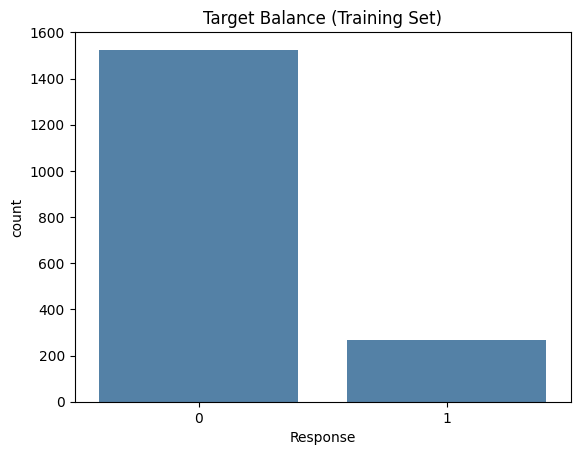

In [27]:
# 1. Target balance in the training set
print(eda["Response"].value_counts())
print("Response rate:", round(eda["Response"].mean() * 100, 1), "%")
print("Accuracy of always predicting 'no response':", round((1 - eda["Response"].mean()) * 100, 1), "%")

sns.countplot(x="Response", data=eda, color="steelblue")
plt.title("Target Balance (Training Set)")
plt.show()

In [28]:
# 2. Missing values and whether they relate to the target
print("Missing values:")
print(eda.isnull().sum()[eda.isnull().sum() > 0])

print("\nResponse rate by whether Income is missing:")
print(eda.groupby(eda["Income"].isnull())["Response"].agg(["count", "mean"]))

Missing values:
Income    16
dtype: int64

Response rate by whether Income is missing:
        count      mean
Income                 
False    1776  0.149775
True       16  0.062500


In [29]:
# 3. Outliers: count values outside 1.5 x IQR for each numeric column
def count_outliers(column):
    q1 = column.quantile(0.25)
    q3 = column.quantile(0.75)
    iqr = q3 - q1
    return ((column < q1 - 1.5 * iqr) | (column > q3 + 1.5 * iqr)).sum()

outlier_summary = pd.DataFrame({
    "min": eda[numeric_columns].min(),
    "median": eda[numeric_columns].median(),
    "max": eda[numeric_columns].max(),
    "skew": eda[numeric_columns].skew().round(2),
    "outliers": [count_outliers(eda[c].dropna()) for c in numeric_columns]
})
outlier_summary

,min,median,max,skew,outliers
Year_Birth,1899.0,1970.0,1996.0,-0.30,2
Income,1730.0,51741.5,666666.0,7.59,7
Kidhome,0.0,0.0,2.0,0.64,0
Teenhome,0.0,0.0,2.0,0.42,0
Recency,0.0,50.0,99.0,-0.01,0
MntWines,0.0,178.5,1493.0,1.13,25
MntFruits,0.0,8.0,199.0,2.07,182
MntMeatProducts,0.0,69.0,1725.0,2.09,133
MntFishProducts,0.0,12.0,259.0,1.85,175
MntSweetProducts,0.0,8.0,197.0,2.04,187
